In [7]:
from pathlib import Path
import sys
import pandas as pd
import torch
from torch.utils.data import DataLoader

def find_project_root(start: Path) -> Path:
    """
    Walk upwards from `start` until we find a directory that has 'src' and 'data'.
    """
    cur = start.resolve()
    for p in [cur] + list(cur.parents):
        if (p / "src").is_dir() and (p / "data").is_dir():
            return p
    raise RuntimeError(f"Could not find project root starting from {start}")

# 1) Detect project root
cwd = Path.cwd()
project_root = find_project_root(cwd)
print("CWD         :", cwd)
print("PROJECT_ROOT:", project_root)

# 2) Add project_root to sys.path if needed
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))
print("project_root in sys.path:", str(project_root) in sys.path)

# 3) Inspect src/ contents
src_dir = project_root / "src"
print("\nsrc/ directory listing:")
for p in sorted(src_dir.iterdir()):
    print(" -", p.name)

# 4) Now import from src.domain_models / src.domain_datasets
from src.models import DomainCNN
from src.datasets import DomainClassificationDataset, pad_collate_fn

print("\nImported DomainCNN and DomainClassificationDataset successfully.")

# 5) Paths for data + checkpoint
META_DIR = project_root / "data" / "processed" / "metadata"
CSV_PATH = META_DIR / "domain_classification_sentences.csv"
CHECKPOINT_PATH = project_root / "checkpoints" / "domain_cnn_best.pt"

print("\nCSV_PATH       :", CSV_PATH)
print("CHECKPOINT_PATH:", CHECKPOINT_PATH)

# 6) Quick CSV sanity
df = pd.read_csv(CSV_PATH)
print("\nCSV shape:", df.shape)
print("hf_split values:", df["hf_split"].unique())
print("domain_label counts:\n", df["domain_label"].value_counts())

# 7) Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("\nUsing device:", device)

# 8) Build test dataset & loader
test_ds = DomainClassificationDataset(
    csv_path=CSV_PATH,
    project_root=project_root,
    split="test",
)

test_loader = DataLoader(
    test_ds,
    batch_size=64,
    shuffle=False,
    collate_fn=pad_collate_fn,
)

# 9) Load model + checkpoint
model = DomainCNN().to(device)
print("\nModel:", model.__class__.__name__)

if CHECKPOINT_PATH.exists():
    state = torch.load(CHECKPOINT_PATH, map_location=device)
    model.load_state_dict(state)
    print("Loaded checkpoint from:", CHECKPOINT_PATH)
else:
    print("WARNING: checkpoint not found, using randomly initialized model!")

model.eval()


CWD         : /home/hpc/iwi5/iwi5384h/projects/handwriting_forge_project/notebooks
PROJECT_ROOT: /home/hpc/iwi5/iwi5384h/projects/handwriting_forge_project
project_root in sys.path: True

src/ directory listing:
 - .ipynb_checkpoints
 - __init__.py
 - __pycache__
 - config.py
 - data_pipeline.py
 - datasets.py
 - eval.py
 - models.py
 - train.py
 - utils.py

Imported DomainCNN and DomainClassificationDataset successfully.

CSV_PATH       : /home/hpc/iwi5/iwi5384h/projects/handwriting_forge_project/data/processed/metadata/domain_classification_sentences.csv
CHECKPOINT_PATH: /home/hpc/iwi5/iwi5384h/projects/handwriting_forge_project/checkpoints/domain_cnn_best.pt

CSV shape: (19602, 7)
hf_split values: ['test' 'train' 'validation']
domain_label counts:
 domain_label
0    9801
1    9801
Name: count, dtype: int64

Using device: cpu
DomainClassificationDataset: 5506 samples (csv='domain_classification_sentences.csv', split='test')

Model: DomainCNN
Loaded checkpoint from: /home/hpc/iwi5/iwi

DomainCNN(
  (conv_block): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
  )
  (fc): Linear(in_features=128, out_features=2, bias=True)
)

In [8]:
import numpy as np

all_true = []
all_pred = []
all_prob_fake = []  # probability for class 1 (Emuru/fake)
all_sources = []
all_idxs = []
all_texts = []

model.eval()

with torch.no_grad():
    for batch in test_loader:
        images = batch["images"].to(device)   # (B, 1, 64, W_max)
        labels = batch["labels"].to(device)   # (B,)

        logits = model(images)                # (B, 2)
        probs = torch.softmax(logits, dim=1)  # (B, 2)
        pred = logits.argmax(dim=1)           # (B,)

        all_true.extend(labels.cpu().numpy().tolist())
        all_pred.extend(pred.cpu().numpy().tolist())
        all_prob_fake.extend(probs[:, 1].cpu().numpy().tolist())  # class 1 = fake

        all_sources.extend(batch["sources"])
        all_idxs.extend(batch["idxs"])
        all_texts.extend(batch["texts"])

# Build DataFrame with results
test_results_df = pd.DataFrame({
    "true_label": all_true,
    "pred_label": all_pred,
    "prob_fake": all_prob_fake,
    "source": all_sources,
    "idx": all_idxs,
    "text": all_texts,
})

print("test_results_df shape:", test_results_df.shape)
print("\nHead:")
display(test_results_df.head())

# Quick accuracy sanity check
acc = (test_results_df["true_label"] == test_results_df["pred_label"]).mean()
print(f"\nTest accuracy recomputed from predictions: {acc*100:.2f}%")


test_results_df shape: (5506, 6)

Head:


,true_label,pred_label,prob_fake,source,idx,text
0,0,0,0.257375,iam,7957,commerce may be kept going - though if ever
1,0,0,0.059673,iam,9341,"' Be silent , woman , and listen , ' Band Appa..."
2,1,1,0.725333,emuru,8143,"Easterly winds , on the other hand ,"
3,1,1,0.785072,emuru,10368,"just dusty-grey but muddy , slimy even ."
4,0,0,0.056946,iam,8651,needed taxation in order to supplement



Test accuracy recomputed from predictions: 99.96%


In [9]:
import numpy as np

# Confusion matrix: rows = true, cols = pred
num_classes = 2
cm = np.zeros((num_classes, num_classes), dtype=int)

for t, p in zip(test_results_df["true_label"], test_results_df["pred_label"]):
    cm[t, p] += 1

print("Confusion matrix (rows = true, cols = pred):")
print("       pred=0    pred=1")
print(f"true=0   {cm[0,0]:6d}   {cm[0,1]:6d}")
print(f"true=1   {cm[1,0]:6d}   {cm[1,1]:6d}")

# Per-class accuracy (recall)
acc_class0 = cm[0,0] / cm[0].sum() if cm[0].sum() > 0 else 0.0
acc_class1 = cm[1,1] / cm[1].sum() if cm[1].sum() > 0 else 0.0

print(f"\nPer-class accuracy:")
print(f"  Class 0 (IAM / genuine): {acc_class0*100:.2f}%")
print(f"  Class 1 (Emuru / fake) : {acc_class1*100:.2f}%")


Confusion matrix (rows = true, cols = pred):
       pred=0    pred=1
true=0     2752        1
true=1        1     2752

Per-class accuracy:
  Class 0 (IAM / genuine): 99.96%
  Class 1 (Emuru / fake) : 99.96%


Number of misclassified test samples: 2
Misclassified merged shape: (2, 8)

Rows to show: 2
idx: 7557 | source: emuru
text: 'manuscripts . A common size of column would hold'
true_label    : 1 (0=IAM/genuine, 1=Emuru/fake)
pred_label    : 0
prob_fake (p(class=1)) = 0.4310
filepath: data/raw/emuru/sentences/iam_07557_sentence.png


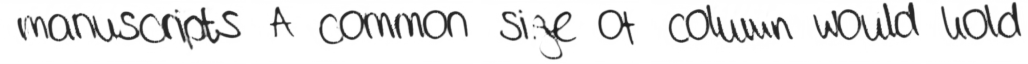

idx: 9160 | source: iam
text: 'lion munching , or arrows where it hurts most . Or'
true_label    : 0 (0=IAM/genuine, 1=Emuru/fake)
pred_label    : 1
prob_fake (p(class=1)) = 0.5298
filepath: data/raw/iam/iam_09160.png


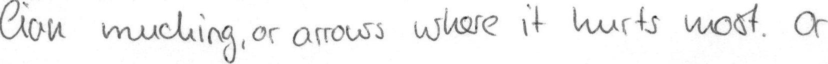

In [11]:
from IPython.display import display
from PIL import Image
from src.datasets import load_line_image  # reuse our resize function

# 1) Find misclassified rows
mis_df = test_results_df[test_results_df["true_label"] != test_results_df["pred_label"]].copy()
print("Number of misclassified test samples:", len(mis_df))

# 2) Join with original CSV to get filepaths
#    (df was loaded earlier from CSV_PATH)
df_test = df[df["hf_split"] == "test"].copy()

# Merge on idx + source to pull filepath (should be unique per (idx, source) in test)
mis_merged = mis_df.merge(
    df_test[["idx", "source", "filepath", "domain_label"]],
    on=["idx", "source"],
    how="left",
    suffixes=("", "_orig")
)

print("Misclassified merged shape:", mis_merged.shape)

if len(mis_merged) == 0:
    print("\nNo hard misclassifications found 🎉")
    print("Let's instead look at *borderline* examples (prob_fake ≈ 0.5).")

    # Borderline = smallest distance to 0.5
    test_results_df["dist_to_0_5"] = (test_results_df["prob_fake"] - 0.5).abs()
    borderline = test_results_df.sort_values("dist_to_0_5").head(8)

    borderline_merged = borderline.merge(
        df_test[["idx", "source", "filepath", "domain_label"]],
        on=["idx", "source"],
        how="left",
        suffixes=("", "_orig")
    )

    rows_to_show = borderline_merged
else:
    # Show up to 8 misclassified (or fewer if <8)
    rows_to_show = mis_merged.head(8)

print("\nRows to show:", len(rows_to_show))

for i, row in rows_to_show.iterrows():
    print("=" * 80)
    print(f"idx: {row['idx']} | source: {row['source']}")
    print(f"text: {repr(row['text'])}")
    print(f"true_label    : {row['true_label']} (0=IAM/genuine, 1=Emuru/fake)")
    print(f"pred_label    : {row['pred_label']}")
    print(f"prob_fake (p(class=1)) = {row['prob_fake']:.4f}")
    print(f"filepath: {row['filepath']}")

    img_path = project_root / row["filepath"]

    try:
        # Show the resized image the model actually sees
        t = load_line_image(img_path)  # (1, 64, W)
        arr = (t.squeeze(0).numpy() * 255).astype("uint8")
        pil_img = Image.fromarray(arr, mode="L")
        display(pil_img)
    except Exception as e:
        print("  Could not load/display image:", e)


Feature matrix shape: (5506, 128)
t-SNE embedding shape: (5506, 2)


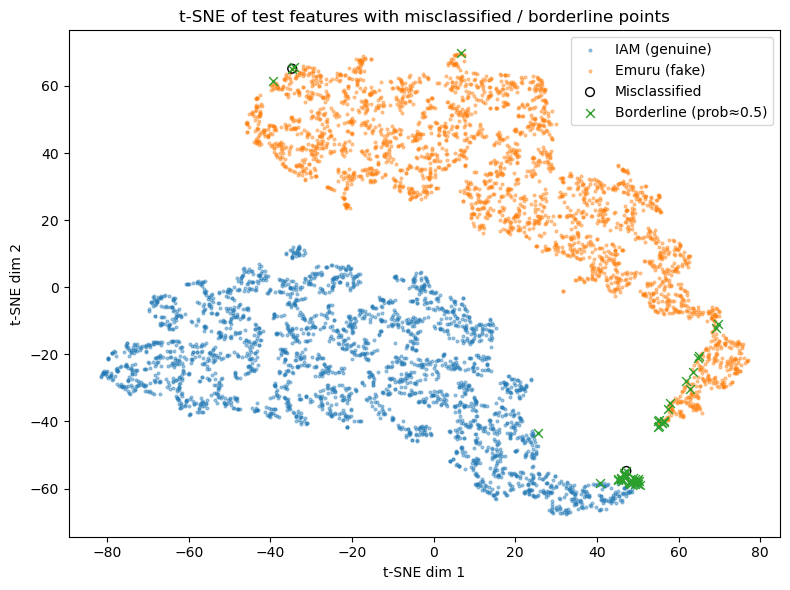

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# 1) Extract features + predictions for the whole test set again

all_feats = []
all_true = []
all_pred = []
all_prob_fake = []
all_sources = []
all_idxs = []
all_texts = []

model.eval()
with torch.no_grad():
    for batch in test_loader:
        images = batch["images"].to(device)   # (B, 1, 64, W_max)
        labels = batch["labels"]
        sources = batch["sources"]
        idxs = batch["idxs"]
        texts = batch["texts"]

        logits = model(images)                # (B, 2)
        probs = torch.softmax(logits, dim=1)
        pred = logits.argmax(dim=1)

        # features from conv_block + global mean pool
        feats = model.conv_block(images)      # (B, C, H', W')
        feats = feats.mean(dim=[2, 3])        # (B, C)

        all_feats.append(feats.cpu().numpy())
        all_true.extend(labels.cpu().numpy().tolist())
        all_pred.extend(pred.cpu().numpy().tolist())
        all_prob_fake.extend(probs[:, 1].cpu().numpy().tolist())
        all_sources.extend(sources)
        all_idxs.extend(idxs)
        all_texts.extend(texts)

X = np.concatenate(all_feats, axis=0)  # (N, C)
y_true = np.array(all_true)
y_pred = np.array(all_pred)
prob_fake = np.array(all_prob_fake)

print("Feature matrix shape:", X.shape)

# 2) t-SNE to 2D
tsne = TSNE(
    n_components=2,
    init="random",
    learning_rate="auto",
    random_state=42,
    perplexity=30,
)
X_emb = tsne.fit_transform(X)
print("t-SNE embedding shape:", X_emb.shape)

# 3) Build a small DataFrame to align with test_results_df-style info
vis_df = pd.DataFrame({
    "true_label": y_true,
    "pred_label": y_pred,
    "prob_fake": prob_fake,
    "source": all_sources,
    "idx": all_idxs,
    "text": all_texts,
})

# Misclassified & borderline masks
mis_mask = (vis_df["true_label"] != vis_df["pred_label"]).to_numpy()

vis_df["dist_to_0_5"] = (vis_df["prob_fake"] - 0.5).abs()
borderline_idx = vis_df["dist_to_0_5"].nsmallest(50).index
borderline_mask = np.zeros(len(vis_df), dtype=bool)
borderline_mask[borderline_idx.to_numpy()] = True

iam_mask = (vis_df["true_label"].to_numpy() == 0)
emu_mask = (vis_df["true_label"].to_numpy() == 1)

# 4) Plot
plt.figure(figsize=(8, 6))

plt.scatter(
    X_emb[iam_mask, 0],
    X_emb[iam_mask, 1],
    s=4,
    alpha=0.4,
    label="IAM (genuine)",
)
plt.scatter(
    X_emb[emu_mask, 0],
    X_emb[emu_mask, 1],
    s=4,
    alpha=0.4,
    label="Emuru (fake)",
)

# Misclassified in circles
if mis_mask.any():
    plt.scatter(
        X_emb[mis_mask, 0],
        X_emb[mis_mask, 1],
        s=40,
        edgecolors="k",
        facecolors="none",
        linewidths=1.0,
        label="Misclassified",
    )

# Borderline near prob≈0.5
plt.scatter(
    X_emb[borderline_mask, 0],
    X_emb[borderline_mask, 1],
    s=40,
    marker="x",
    linewidths=1.0,
    label="Borderline (prob≈0.5)",
)

plt.title("t-SNE of test features with misclassified / borderline points")
plt.xlabel("t-SNE dim 1")
plt.ylabel("t-SNE dim 2")
plt.legend()
plt.tight_layout()
plt.show()
